In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


BEST MODEL SELECTION (Stabilized Variance)
Optimal Polynomial Degree : Degree 3
Validation MSE             : 1.1251
Performance on TEST Set   : 1.0094 (MSE)


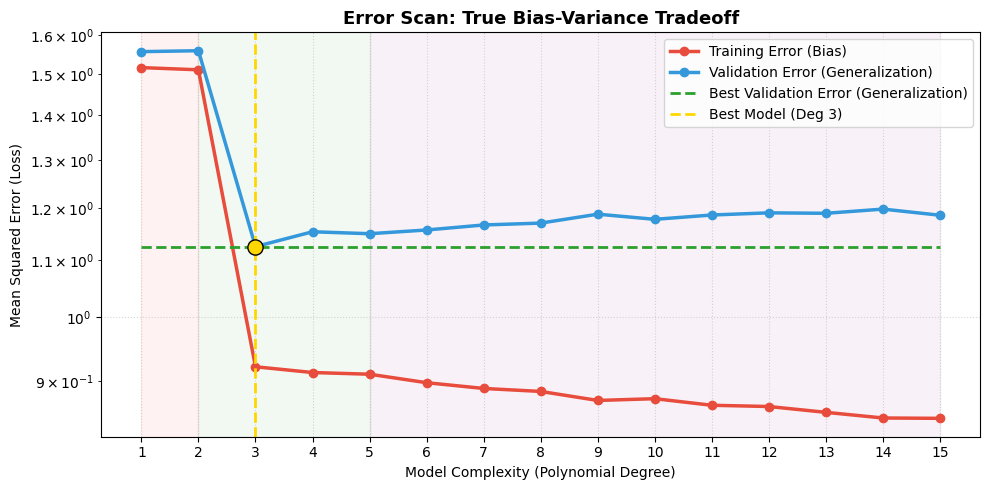

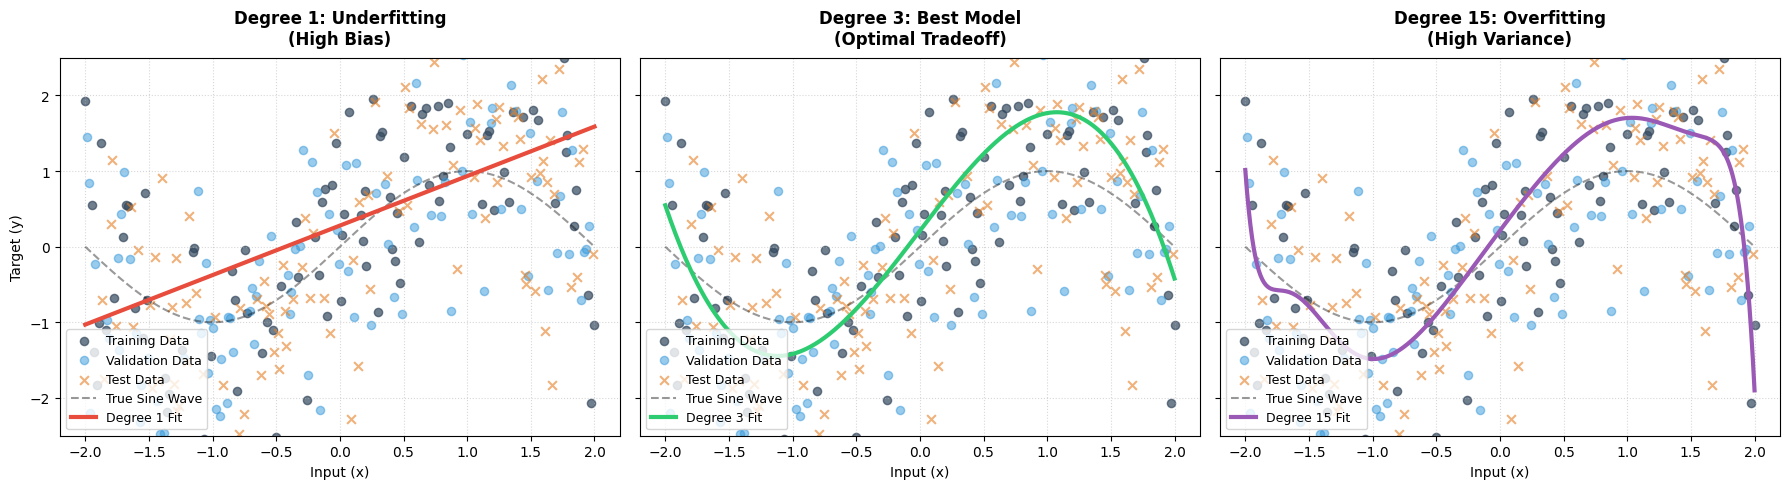

In [22]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. SETUP DATA (Stabilized Sample Size)
# ==========================================
torch.manual_seed(42)
np.random.seed(42)

# Generate 300 points total (100 Train / 100 Val / 100 Test)
X_all = torch.linspace(-2, 2, 300).unsqueeze(1)
y_all = 1.5 * torch.sin(X_all * np.pi / 2) + torch.randn(X_all.shape) 

indices = torch.randperm(300)
train_idx, val_idx, test_idx = indices[:100], indices[100:200], indices[200:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val = X_all[val_idx], y_all[val_idx]
X_test, y_test = X_all[test_idx], y_all[test_idx]

# Dense line for generating smooth visual curves
X_line = torch.linspace(-2, 2, 300).unsqueeze(1)
y_line = torch.sin(X_line * np.pi / 2)

# ==========================================
# 2. FEATURE SCALING HELPER
# ==========================================
def get_scaled_poly_features(X_target, degree, X_reference):
    """
    Generates polynomial features for X_target, scaled strictly using the 
    maximum values calculated from X_reference (Train Set) to avoid data leakage.
    """
    raw_target = torch.cat([X_target**i for i in range(1, degree + 1)], dim=1)
    raw_ref = torch.cat([X_reference**i for i in range(1, degree + 1)], dim=1)
    
    col_max, _ = torch.max(torch.abs(raw_ref), dim=0, keepdim=True)
    col_max = torch.clamp(col_max, min=1e-8)
    
    return raw_target / col_max

# ==========================================
# 3. COMPLEXITY SCAN LOOP
# ==========================================
max_degree = 15
degrees = list(range(1, max_degree + 1))
train_errors = []
val_errors = []

trained_models = {}
criterion = nn.MSELoss()

for deg in degrees:
    X_poly_train = get_scaled_poly_features(X_train, deg, X_train)
    X_poly_val   = get_scaled_poly_features(X_val, deg, X_train)
    
    model = nn.Linear(deg, 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
    
    # Train to stable convergence
    for epoch in range(1500):
        optimizer.zero_grad()
        loss = criterion(model(X_poly_train), y_train)
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        train_loss = criterion(model(X_poly_train), y_train).item()
        val_loss = criterion(model(X_poly_val), y_val).item()
        
    train_errors.append(train_loss)
    val_errors.append(val_loss)
    
    trained_models[deg] = model

# ==========================================
# 4. EVALUATE WINNER ON HIDDEN TEST SET
# ==========================================
best_degree = degrees[np.argmin(val_errors)]
best_model = trained_models[best_degree]

X_poly_test = get_scaled_poly_features(X_test, best_degree, X_train)
best_model.eval()
with torch.no_grad():
    test_loss = criterion(best_model(X_poly_test), y_test).item()

print("=" * 60)
print(f"BEST MODEL SELECTION (Stabilized Variance)")
print("=" * 60)
print(f"Optimal Polynomial Degree : Degree {best_degree}")
print(f"Validation MSE             : {min(val_errors):.4f}")
print(f"Performance on TEST Set   : {test_loss:.4f} (MSE)")
print("=" * 60)

# ==========================================
# 5. PLOT 1: THE ERROR SCAN CURVES
# ==========================================
plt.figure(figsize=(10, 5))
plt.plot(degrees, train_errors, 'o-', color='#e74c3c', linewidth=2.5, label='Training Error (Bias)')
plt.plot(degrees, val_errors, 'o-', color='#3498db', linewidth=2.5, label='Validation Error (Generalization)')

plt.title('Error Scan: True Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error (Loss)')
plt.xticks(degrees)
plt.yscale('log') 
plt.grid(True, linestyle=':', alpha=0.5)

plt.axvspan(1, 2, color='red', alpha=0.05)
plt.axvspan(2, 5, color='green', alpha=0.05)
plt.axvspan(5, max_degree, color='purple', alpha=0.05)
plt.plot(degrees, np.min(val_errors)*np.ones_like(degrees), color='tab:green', linestyle='--', linewidth=2, label='Best Validation Error (Generalization)')

plt.axvline(x=best_degree, color='gold', linestyle='--', linewidth=2, label=f'Best Model (Deg {best_degree})')
plt.scatter(best_degree, min(val_errors), color='gold', s=120, zorder=5, edgecolor='black')
plt.legend()
plt.tight_layout()

# ==========================================
# 6. PLOT 2: VISUAL FITS COMPARISON
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
plot_degrees = [1, best_degree, 15]
titles = [
    "Degree 1: Underfitting\n(High Bias)",
    f"Degree {best_degree}: Best Model\n(Optimal Tradeoff)",
    "Degree 15: Overfitting\n(High Variance)"
]
colors = ['#e74c3c', '#2ecc71', '#9b59b6']

for i, deg in enumerate(plot_degrees):
    ax = axes[i]
    
    # Generate predictions across the continuous line space
    X_poly_line = get_scaled_poly_features(X_line, deg, X_train)
    m = trained_models[deg]
    m.eval()
    with torch.no_grad():
        line_preds = m(X_poly_line).numpy()
        
    # Plot data points with explicit group identities
    ax.scatter(X_train.numpy(), y_train.numpy(), color='#34495e', alpha=0.7, s=35, label='Training Data')
    ax.scatter(X_val.numpy(), y_val.numpy(), color='#3498db', alpha=0.5, s=35, label='Validation Data')
    ax.scatter(X_test.numpy(), y_test.numpy(), color='#e67e22', marker='x', alpha=0.6, s=40, label='Test Data')
    
    # Plot true vs predicted profiles
    ax.plot(X_line.numpy(), y_line.numpy(), 'k--', alpha=0.4, label='True Sine Wave')
    ax.plot(X_line.numpy(), line_preds, color=colors[i], linewidth=3, label=f'Degree {deg} Fit')
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Input (x)')
    ax.set_ylim(-2.5, 2.5)
    ax.grid(True, linestyle=':', alpha=0.5)
    if i == 0:
        ax.set_ylabel('Target (y)')
    ax.legend(loc='lower left', fontsize=9)

plt.tight_layout()
plt.show()

FINAL PERFORMANCE SUMMARY
1. Single Neuron        | Train: 0.2986 | Val: 0.3328 | Test: 0.3122
2. 3-Layer MLP (No Reg) | Train: 0.0065 | Val: 0.2728 | Test: 0.2400
3. 3-Layer MLP + Reg    | Train: 0.0647 | Val: 0.1209 | Test: 0.0789
---------------------------------------------------------------------------
WINNER (Selected by Val Performance): 3-Layer MLP With Regularization (Balanced)
   -> Final Unseen Test Set MSE: 0.0789


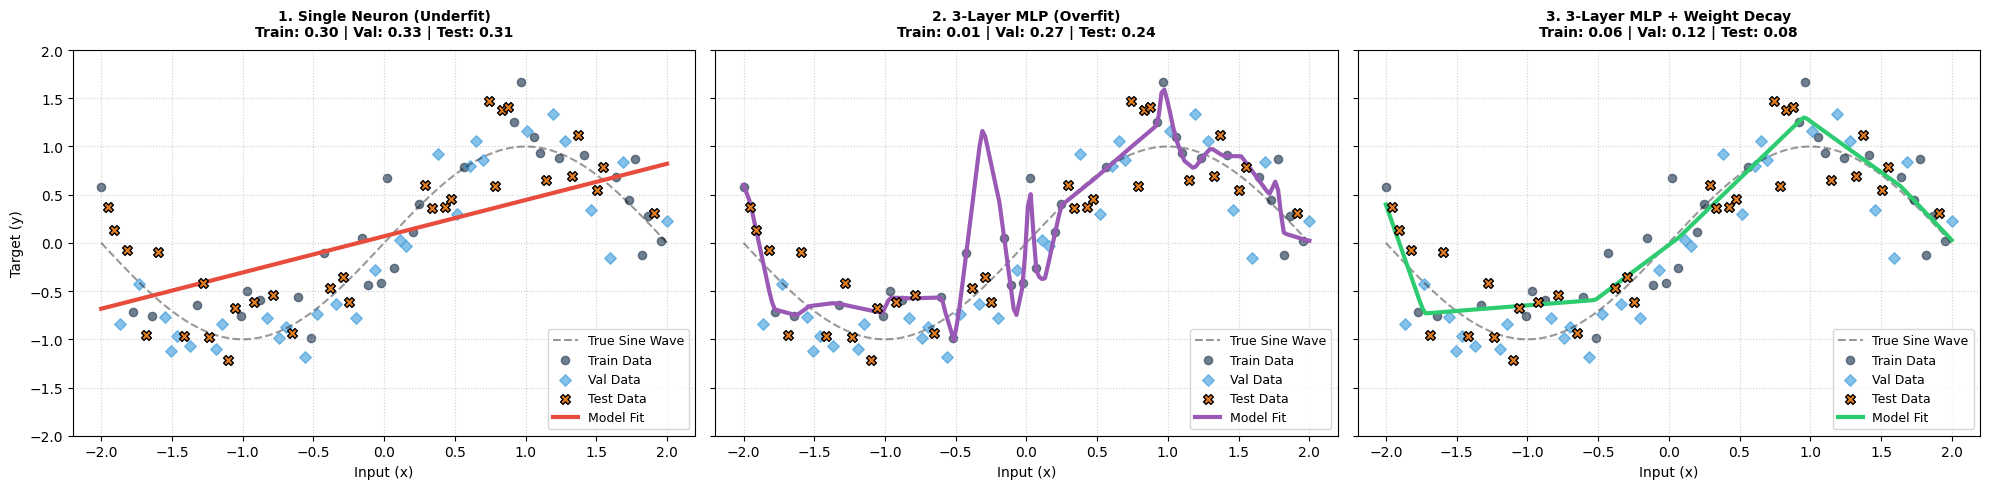

In [29]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Data (Noisy Sine Wave with 3-Way Split)
torch.manual_seed(42)
np.random.seed(42)

# Generate an expanded dataset to cleanly accommodate 3 distinct splits
X_all = torch.linspace(-2, 2, 90).unsqueeze(1)
y_all = torch.sin(X_all * np.pi / 2) + torch.randn(X_all.shape) * 0.3

# Shuffle and split equally (1/3 Train, 1/3 Val, 1/3 Test)
indices = torch.randperm(90)
train_idx, val_idx, test_idx = indices[:30], indices[30:60], indices[60:]

X_train, y_train = X_all[train_idx], y_all[train_idx]
X_val, y_val     = X_all[val_idx], y_all[val_idx]
X_test, y_test   = X_all[test_idx], y_all[test_idx]

# Dense line for plotting smooth model predictions
X_line = torch.linspace(-2, 2, 200).unsqueeze(1)
y_line = torch.sin(X_line * np.pi / 2)

# 2. Define Architectures

# Model A: Single Neuron (Linear Regression)
class SingleNeuron(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)
    def forward(self, x):
        return self.linear(x)

# Model B & C: Deep MLP (3 Layers)
class DeepMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.network(x)

# Instantiate models
model_neuron = SingleNeuron()
model_mlp = DeepMLP()
model_mlp_reg = DeepMLP()

# 3. Define Optimizers (Applying Weight Decay only to the regularized model)
criterion = nn.MSELoss()
epochs = 5000
lr = 0.01

opt_neuron = torch.optim.Adam(model_neuron.parameters(), lr=lr)
opt_mlp    = torch.optim.Adam(model_mlp.parameters(), lr=lr)
opt_reg    = torch.optim.Adam(model_mlp_reg.parameters(), lr=lr, weight_decay=3e-3)

# 4. Training Loop (Using Training Set Only)
for epoch in range(epochs):
    # Train Single Neuron
    model_neuron.train()
    loss_n = criterion(model_neuron(X_train), y_train)
    opt_neuron.zero_grad()
    loss_n.backward()
    opt_neuron.step()
    
    # Train Unregularized MLP
    model_mlp.train()
    loss_m = criterion(model_mlp(X_train), y_train)
    opt_mlp.zero_grad()
    loss_m.backward()
    opt_mlp.step()
    
    # Train Regularized MLP
    model_mlp_reg.train()
    loss_r = criterion(model_mlp_reg(X_train), y_train)
    opt_reg.zero_grad()
    loss_r.backward()
    opt_reg.step()

# 5. Evaluate Performance on Train, Val, and Hidden Test Sets
model_neuron.eval()
model_mlp.eval()
model_mlp_reg.eval()

with torch.no_grad():
    # Calculate Final Train Losses
    train_loss_neuron = criterion(model_neuron(X_train), y_train).item()
    train_loss_mlp    = criterion(model_mlp(X_train), y_train).item()
    train_loss_reg    = criterion(model_mlp_reg(X_train), y_train).item()

    # Calculate Final Validation Losses (Used for picking/tuning models)
    val_loss_neuron   = criterion(model_neuron(X_val), y_val).item()
    val_loss_mlp      = criterion(model_mlp(X_val), y_val).item()
    val_loss_reg      = criterion(model_mlp_reg(X_val), y_val).item()

    # Calculate Final Test Losses (The final blind evaluation benchmark)
    test_loss_neuron  = criterion(model_neuron(X_test), y_test).item()
    test_loss_mlp     = criterion(model_mlp(X_test), y_test).item()
    test_loss_reg     = criterion(model_mlp_reg(X_test), y_test).item()
    
    # Generate dense lines for visual evaluation plots
    pred_neuron = model_neuron(X_line)
    pred_mlp    = model_mlp(X_line)
    pred_reg    = model_mlp_reg(X_line)

# 6. Print Performance Summary & Identify Best Model (Using Validation set to pick)
print("=" * 75)
print("FINAL PERFORMANCE SUMMARY")
print("=" * 75)
print(f"1. Single Neuron        | Train: {train_loss_neuron:.4f} | Val: {val_loss_neuron:.4f} | Test: {test_loss_neuron:.4f}")
print(f"2. 3-Layer MLP (No Reg) | Train: {train_loss_mlp:.4f} | Val: {val_loss_mlp:.4f} | Test: {test_loss_mlp:.4f}")
print(f"3. 3-Layer MLP + Reg    | Train: {train_loss_reg:.4f} | Val: {val_loss_reg:.4f} | Test: {test_loss_reg:.4f}")
print("-" * 75)

# Selection criteria based strictly on validation results
val_results = {
    "Single Neuron (Underfitting)": (val_loss_neuron, test_loss_neuron),
    "3-Layer MLP Without Regularization (Overfitting)": (val_loss_mlp, test_loss_mlp),
    "3-Layer MLP With Regularization (Balanced)": (val_loss_reg, test_loss_reg)
}
best_model_name = min(val_results, key=lambda k: val_results[k][0])
best_model_test_score = val_results[best_model_name][1]

print(f"WINNER (Selected by Val Performance): {best_model_name}")
print(f"   -> Final Unseen Test Set MSE: {best_model_test_score:.4f}")
print("=" * 75)

# 7. Plotting the Comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
titles = [
    f"1. Single Neuron (Underfit)\nTrain: {train_loss_neuron:.2f} | Val: {val_loss_neuron:.2f} | Test: {test_loss_neuron:.2f}", 
    f"2. 3-Layer MLP (Overfit)\nTrain: {train_loss_mlp:.2f} | Val: {val_loss_mlp:.2f} | Test: {test_loss_mlp:.2f}", 
    f"3. 3-Layer MLP + Weight Decay\nTrain: {train_loss_reg:.2f} | Val: {val_loss_reg:.2f} | Test: {test_loss_reg:.2f}"
]
predictions = [pred_neuron, pred_mlp, pred_reg]
colors = ['#e74c3c', '#9b59b6', '#2ecc71']

for i, ax in enumerate(axes):
    # Plot baseline truth
    ax.plot(X_line.numpy(), y_line.numpy(), 'k--', alpha=0.4, label='True Sine Wave')
    
    # Plot three distinct data split profiles
    ax.scatter(X_train.numpy(), y_train.numpy(), color='#34495e', alpha=0.7, s=35, label='Train Data')
    ax.scatter(X_val.numpy(), y_val.numpy(), color='#3498db', marker='D', alpha=0.6, s=35, label='Val Data')
    ax.scatter(X_test.numpy(), y_test.numpy(), color='#e67e22', marker='X', edgecolor='k', s=50, zorder=3, label='Test Data')
    
    # Plot model fit representation
    ax.plot(X_line.numpy(), predictions[i].numpy(), color=colors[i], linewidth=3, label='Model Fit')
    
    ax.set_title(titles[i], fontsize=10, fontweight='bold', pad=10)
    ax.set_xlabel('Input (x)')
    ax.set_ylim(-2, 2)
    ax.grid(True, linestyle=':', alpha=0.6)
    if i == 0:
        ax.set_ylabel('Target (y)')
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()